In [46]:
import numpy as np
from collections import Counter
from sklearn.model_selection import train_test_split,cross_val_score
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import accuracy_score
from mlxtend.plotting import plot_decision_regions
import matplotlib.pyplot as plt
from sklearn.tree import DecisionTreeClassifier
from sklearn.decomposition import PCA

In [47]:
class Node:
    def __init__(self,feature = None,threshold = None,left = None , right = None,*,value=None):
        self.feature = feature
        self.threshold = threshold
        self.left = left
        self.right = right
        self.value = value

    def is_leaf_node(self):
        return self.value is not None


class DecisionTree:
    def __init__(self,min_samples_split=2,max_depth = 100,n_features = None):
        self.min_samples_split = min_samples_split
        self.max_depth = max_depth
        self.n_features = n_features
        self.root = None

    def fit(self,x_train,y_train):
        self.n_features = x_train.shape[1] if not self.n_features else min(x_train.shape[1],self.n_features)
        self.root = self.grow_tree(x_train,y_train)

    def grow_tree(self,x,y,depth=0):
        n_samples,n_feats = x.shape
        n_labels = len(np.unique(y))

        #Check stopping criteria:
        if (depth>=self.max_depth or n_labels == 1 or n_samples < self.min_samples_split):
            leaf_value = self.most_common(y)
            return Node(value=leaf_value)
        
        #Finding best split:
        feat_idx = np.random.choice(n_feats,self.n_features,replace = False)
        best_feat,best_thr = self.best_split(x,y,feat_idx)

        # child nodes:
        left_idxs , right_idxs = self._split(x[:,best_feat],best_thr)
        left = self.grow_tree(x[left_idxs,:],y[left_idxs],depth+1)
        right = self.grow_tree(x[right_idxs,:],y[right_idxs],depth+1)

        return Node(best_feat,best_thr,left,right)

    def best_split(self,x,y,feat_idx):
        best_gain = -1
        split_idx,split_thr = None,None

        for feat_id in feat_idx:
            x_column = x[:,feat_id]
            thresholds = np.unique(x_column)

            for thr in thresholds:
                gain = self.info_gain(y,x_column,thr)

                if gain>best_gain:
                    best_gain = gain
                    split_idx = feat_id
                    split_thr = thr

        return split_idx,split_thr
    def most_common(self,y):
        count = Counter(y)
        
        return count.most_common(1)[0][0]
    
    def info_gain(self,y,x_column,threshold):
        #parent entropy:
        parent_entropy = self.entropy(y)
        
        #create children:
        left_idxs,right_idxs = self._split(x_column,threshold)

        if len(left_idxs)== 0 or len(right_idxs)== 0 :
            return 0
        
        #weighted avg.entropy of children:
        n = len(y)
        n_l,n_r = len(left_idxs),len(right_idxs)
        e_l,e_r = self.entropy(y[left_idxs]) , self.entropy(y[right_idxs])
        child_entropy = (n_l/n)*e_l + (n_r/n)*e_r

        info_gain = parent_entropy - child_entropy
        return info_gain

    def entropy(self,y):
        hist = np.bincount(y)
        ps= hist/len(y)
        return -np.sum([p * np.log2(p) for p in ps if p > 0])
    
    def _split(self,x_column,split_thresh):
        left_idxs = np.argwhere(x_column <= split_thresh).flatten()
        right_idxs = np.argwhere(x_column > split_thresh).flatten()

        return left_idxs,right_idxs
    
    def predict(self,x_test):
        return np.array([self._traverse_tree(x,self.root) for x in x_test])
    
    def _traverse_tree(self,x,node):
        if node.is_leaf_node():
            return node.value
        
        if x[node.feature] <= node.threshold:
            return self._traverse_tree(x,node.left)
        
        return self._traverse_tree(x,node.right)

In [48]:
class RandomForest:
    def __init__(self,n_trees=10,max_depth=10,min_samples_split=2,n_features=None):
        self.n_trees = n_trees
        self.max_depth = max_depth
        self.min_samples_split = min_samples_split
        self.n_features = n_features
        self.trees = []

    def fit(self,x_train,y_train):
        for i in range(self.n_trees):
            x_sample,y_sample = self._random_samples(x_train,y_train)
            tree = DecisionTree(min_samples_split=self.min_samples_split,max_depth=self.max_depth,
                                n_features=self.n_features)
            tree.fit(x_sample,y_sample)
            self.trees.append(tree)

    def predict(self,x_test):
        predictions = np.array([tree.predict(x_test) for tree in self.trees])
        t_preds = np.swapaxes(predictions,0,1)
        predicted_labels = np.array([self._most_common_label(pred) for pred in t_preds])
        return predicted_labels
    
    def _random_samples(self,x,y):
        n_samples = x.shape[0]
        idxs = np.random.choice(n_samples,n_samples,replace=True)
        return x[idxs],y[idxs]
    def _most_common_label(self,y):
        count = Counter(y)
        return count.most_common(1)[0][0]

In [49]:
from sklearn.datasets import load_wine
df = load_wine()
x = df.data
y = df.target

x_train,x_test,y_train,y_test = train_test_split(x,y,test_size=0.2,random_state=42)

# Decomposing deatures using PCA for better visualization

pca = PCA(n_components=2)
x_train = pca.fit_transform(x_train)
x_test = pca.transform(x_test)

In [50]:
rf = RandomForest()
rfc = RandomForestClassifier()
dt = DecisionTreeClassifier()

Accuracy score of self-rf is 0.7777777777777778
Accuracy score of skl. rf is 0.75
Accuracy score of dt is 0.6666666666666666


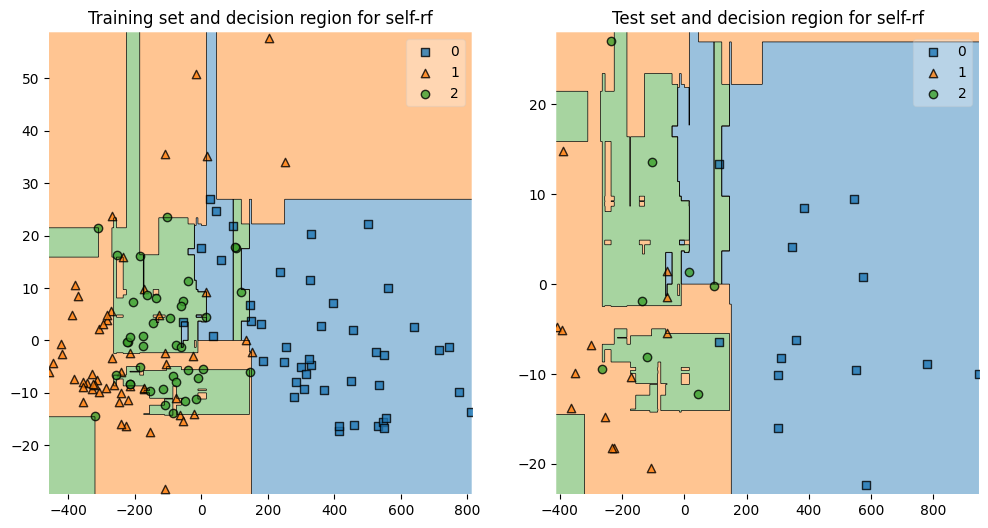

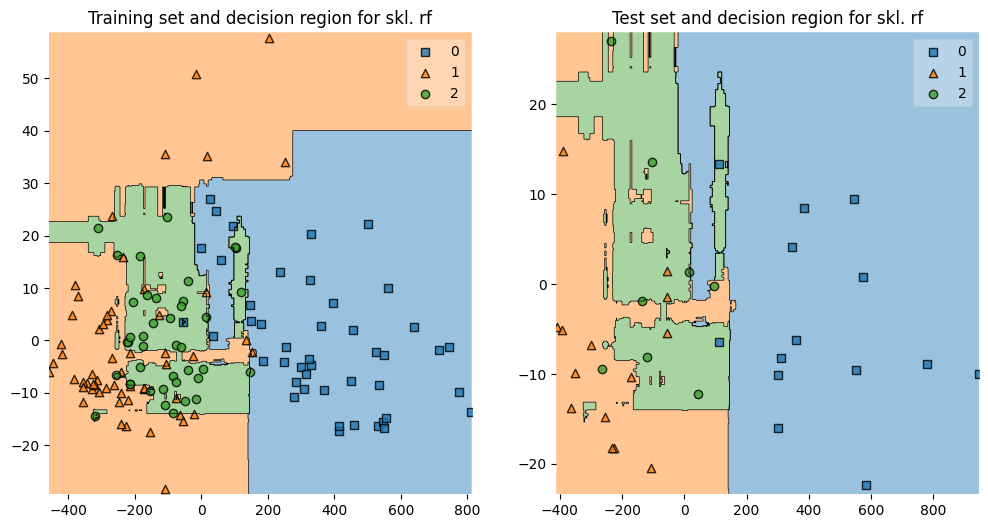

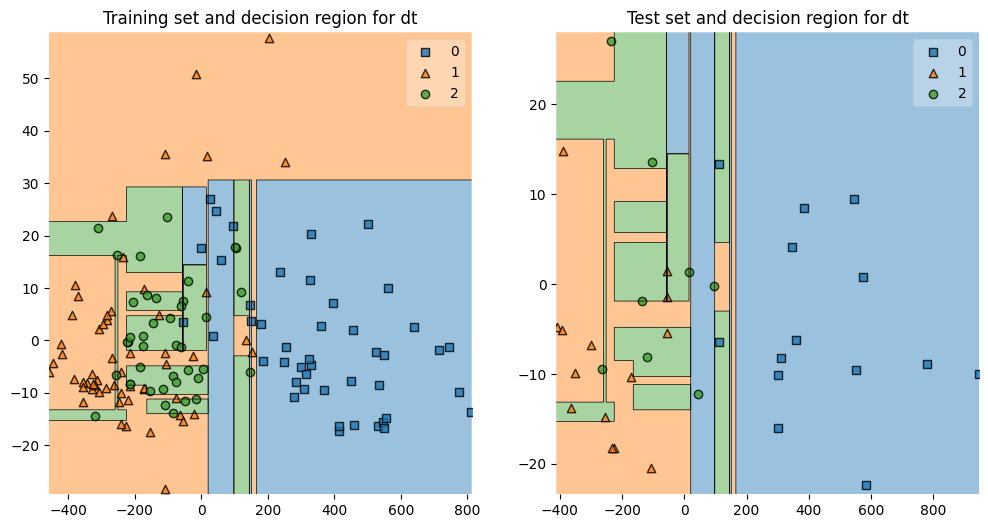

In [ ]:
classifiers = [('self-rf',rf),('skl. rf',rfc),('dt',dt)]
for clf in classifiers:
    clf[1].fit(x_train,y_train)
    plt.figure(figsize=(12,6))
    plt.subplot(121)
    plot_decision_regions(x_train,y_train,clf=clf[1])
    plt.title(f"Training set and decision region for {clf[0]}")
    y_pred = clf[1].predict(x_test)
    print(f"Accuracy score of {clf[0]} is {accuracy_score(y_test,y_pred)}")
    plt.subplot(122)
    plot_decision_regions(x_test,y_test,clf[1])
    plt.title(f"Test set and decision region for {clf[0]}")

# Direct comparison of Decision Region

Text(0.5, 1.0, 'Decsion trees')

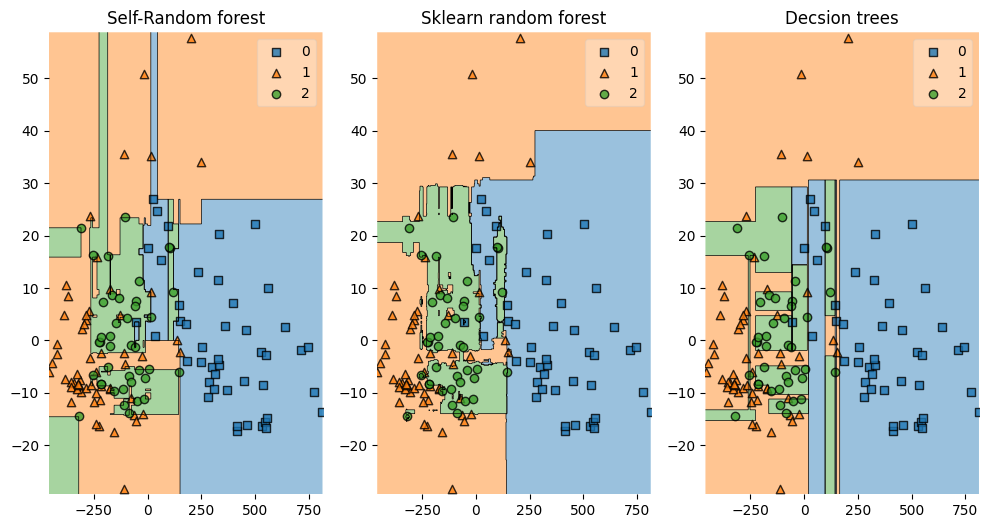

In [52]:
plt.figure(figsize=(12,6))
plt.subplot(131)
plot_decision_regions(x_train,y_train,rf)
plt.title("Self-Random forest")
plt.subplot(132)
plot_decision_regions(x_train,y_train,rfc)
plt.title("Sklearn random forest")
plt.subplot(133)
plot_decision_regions(x_train,y_train,dt)
plt.title("Decsion trees")